# Medicare Provider Fraud Detection
## Logistic Regression with Random Undersampling

This notebook builds a supervised machine learning model to detect fraudulent 
Medicare providers using CMS billing data. Providers are labeled using the 
HHS OIG List of Excluded Individuals and Entities (LEIE), which tracks providers 
excluded from federal healthcare programs for fraud, abuse, and other violations.

**Data:** CMS Medicare Physician & Other Practitioners (9.6M billing records, 
1.17M unique providers)  
**Labels:** HHS OIG LEIE (198 confirmed excluded providers in dataset)  
**Infrastructure:** AWS S3 + Amazon Athena  
**Method:** Random Undersampling (RUS) across 4 class ratios × 10 runs


## 1. Imports

## 2. Data Loading

The dataset was prepared in Amazon Athena by:
1. Aggregating 9.6M billing records to one row per provider
2. Calculating z-scores across three billing signals vs specialty peers
3. Left joining against the LEIE to create binary fraud labels

The resulting CSV contains 1,175,254 providers with 15 features and a binary 
`is_excluded` label (1 = on LEIE, 0 = not excluded).


In [10]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('ff8eaaa3-3d41-4ddf-a7f9-6405b733b453.csv')
print(df.shape)
print(df['is_excluded'].value_counts())


/var/folders/px/59zkv8317_x6cv2gk0v0s76h0000gn/T/ipykernel_3057/53133515.py:8: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('ff8eaaa3-3d41-4ddf-a7f9-6405b733b453.csv')


(1258013, 15)
is_excluded
0    1257815
1        198
Name: count, dtype: int64


In [11]:
features = [
    'unique_procedures',
    'total_services',
    'total_patients',
    'total_patient_days',
    'avg_payment',
    'avg_submitted_charge',
    'services_per_patient',
    'services_per_day',
    'payment_zscore',
    'spp_zscore',
    'spd_zscore'
]

fraud = df[df['is_excluded'] == 1]
clean = df[df['is_excluded'] == 0]

print(f"Fraud cases: {len(fraud)}")
print(f"Clean cases: {len(clean)}")


Fraud cases: 198
Clean cases: 1257815


## 3. Handling Missing Values

82,730 providers have null values in billing columns, likely due to suppressed 
data in the CMS source (CMS suppresses values for providers with fewer than 
11 beneficiaries to protect patient privacy). These rows are dropped before 
modeling. All 198 fraud-labeled providers are retained after dropping nulls.


In [12]:
# Check where nulls are
print(df[features].isnull().sum())

# Drop rows with nulls in feature columns
df = df.dropna(subset=features)

# Redefine fraud and clean after dropping nulls
fraud = df[df['is_excluded'] == 1]
clean = df[df['is_excluded'] == 0]

print(f"After dropping nulls:")
print(f"Fraud cases: {len(fraud)}")
print(f"Clean cases: {len(clean)}")


unique_procedures           0
total_services          82730
total_patients          82730
total_patient_days      82730
avg_payment             82730
avg_submitted_charge    82730
services_per_patient    82730
services_per_day        82730
payment_zscore          82731
spp_zscore              82759
spd_zscore              82759
dtype: int64
After dropping nulls:
Fraud cases: 198
Clean cases: 1175056


## 4. Random Undersampling + Logistic Regression

The dataset is severely imbalanced — 198 fraud cases out of 1.17M providers 
(0.017%). To address this, we use Random Undersampling (RUS) following the 
methodology of Richard A. Bauder and Taghi M. Khoshgoftaar in their academic paper "The Detection of Medicare Fraud Using Machine
Learning Methods with Excluded Provider Labels", testing four class ratios:

- 50:50 (majority:minority)
- 65:35
- 75:25
- 80:20

Each ratio is repeated 10 times with different random seeds to ensure results 
are not dependent on which specific clean providers are sampled. Mean F1 score 
and AUC are reported across all 10 runs.

Features are scaled using StandardScaler before training since logistic 
regression is sensitive to feature magnitude.


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

ratios = {
    '50:50': 1.0,
    '65:35': 35/65,
    '75:25': 25/75,
    '80:20': 20/80
}

results = {}

for ratio_name, ratio in ratios.items():
    ratio_scores = []
    ratio_auc = []
    
    n_fraud = len(fraud)
    n_clean = int(n_fraud / ratio)
    
    for run in range(10):
        # Sample clean providers
        clean_sample = clean.sample(n=n_clean, random_state=run)
        
        # Combine and shuffle
        df_balanced = pd.concat([fraud, clean_sample]).sample(frac=1, random_state=run)
        
        X_res = df_balanced[features]
        y_res = df_balanced['is_excluded']
        
        # Scale features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_res)
        
        # Train model
        model = LogisticRegression(max_iter=1000, solver='saga')
        model.fit(X_scaled, y_res)
        
        # Evaluate
        y_pred = model.predict(X_scaled)
        y_prob = model.predict_proba(X_scaled)[:, 1]
        
        report = classification_report(y_res, y_pred, output_dict=True)
        ratio_scores.append(report['1']['f1-score'])
        ratio_auc.append(roc_auc_score(y_res, y_prob))
    
    results[ratio_name] = {
        'mean_f1': np.mean(ratio_scores),
        'std_f1': np.std(ratio_scores),
        'mean_auc': np.mean(ratio_auc),
        'std_auc': np.std(ratio_auc)
    }



## 5. Results by Class Ratio

In [14]:
print(f"{'Ratio':<10} {'Mean F1':<12} {'Std F1':<12} {'Mean AUC':<12} {'Std AUC'}")
print("-" * 55)
for ratio, scores in results.items():
    print(f"{ratio:<10} {scores['mean_f1']:<12.3f} {scores['std_f1']:<12.3f} {scores['mean_auc']:<12.3f} {scores['std_auc']:.3f}")


Ratio      Mean F1      Std F1       Mean AUC     Std AUC
-------------------------------------------------------
50:50      0.588        0.036        0.672        0.024
65:35      0.229        0.045        0.665        0.019
75:25      0.135        0.031        0.661        0.012
80:20      0.107        0.024        0.655        0.011


## 6. Feature Importance

Logistic regression coefficients indicate which billing signals most strongly 
predict LEIE exclusion. Positive coefficients increase fraud probability, 
negative coefficients decrease it.


In [15]:
# Feature importance from the last trained model
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

print(coef_df)


                 feature  coefficient
9             spp_zscore     0.417050
4            avg_payment     0.309890
3     total_patient_days     0.171969
1         total_services     0.059671
6   services_per_patient    -0.015320
10            spd_zscore    -0.048434
0      unique_procedures    -0.067104
2         total_patients    -0.084915
8         payment_zscore    -0.104028
7       services_per_day    -0.200754
5   avg_submitted_charge    -0.443902


/var/folders/px/59zkv8317_x6cv2gk0v0s76h0000gn/T/ipykernel_3057/273342084.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='coefficient', y='feature',


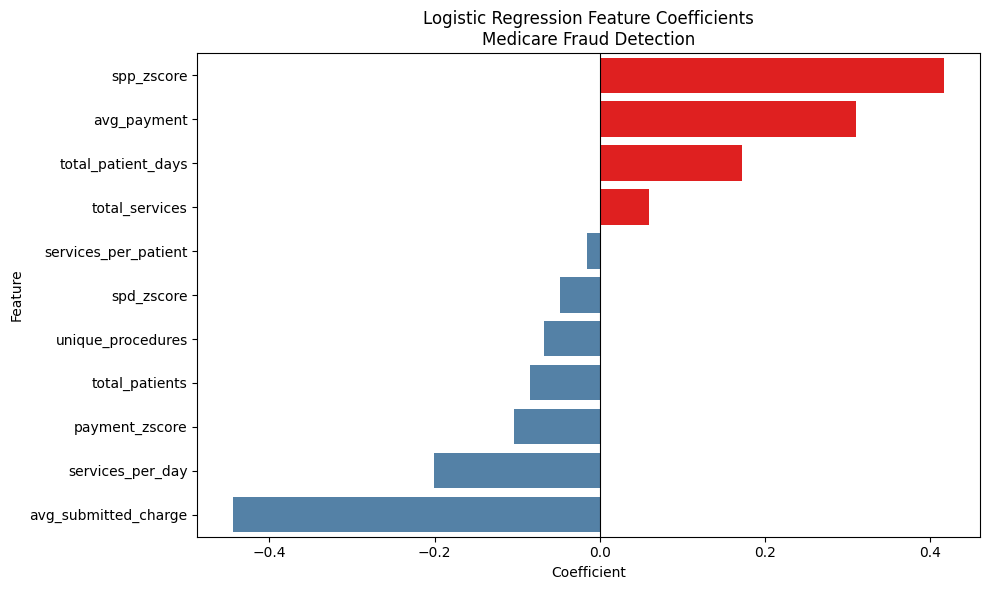

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df, x='coefficient', y='feature', 
            palette=['red' if x > 0 else 'steelblue' for x in coef_df['coefficient']])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Logistic Regression Feature Coefficients\nMedicare Fraud Detection')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()


## 7. Conclusions

**Model Performance:**
The logistic regression achieved a mean AUC of 0.672 at a 50:50 class ratio, 
meaningfully above the 0.5 baseline of a random classifier. F1 score was 
highest at 0.588 under balanced sampling, declining as class imbalance increased.

**Feature Importance:**
`spp_zscore` (services per patient z-score) was the strongest predictor of 
LEIE exclusion (coefficient: 0.417), followed by `avg_payment` (0.310). This 
independently validates the z-score anomaly detection methodology. The model 
confirmed that billing volume relative to specialty peers is the most meaningful 
fraud signal.

**Limitations:**
- Only 198 confirmed LEIE matches limits supervised learning performance
- Labels reflect exclusion status at time of LEIE download, not necessarily 
  during the billing period
- Logistic regression assumes linear relationships — ensemble methods like 
  Random Forest may capture non-linear patterns better

**Next Steps:**
- Train a Random Forest or Gradient Boosting model for comparison
- Incorporate IQR-based anomaly scores as additional features
- Expand labeled dataset using historical LEIE snapshots
